In [26]:
import pandas as pd
import numpy as np
import ast
from pathlib import Path

cwd = Path.cwd()
CSV_PATH = cwd.parent.parent / "tests" / "parameter_grid_neural_net_tests_100_epochs.csv"

In [2]:
df = pd.read_csv(CSV_PATH)
df.head(5)

,trial_num,total_parameters,hidden_layer_sizes,train_MSE,test_MSE,train_RMSE,test_RMSE,train_r2_score,test_r2_score,train_y,train_model_y,test_y,test_model_y
0,1,1387,[],0.770142,1.125844,0.877577,1.061058,-10.0193,-13.8093,"[0.28060001134872437, 0.3165999948978424, 0.00...","[0.35702162981033325, 0.436102032661438, -7.12...","[0.7901999950408936, 0.0538799986243248, 0.253...","[0.8275359869003296, 0.03389115631580353, 0.49..."
1,2,2847,"[2, 4, 8, 2]",0.038502,0.043176,0.196218,0.207789,0.4491,0.4321,"[0.28060001134872437, 0.3165999948978424, 0.00...","[0.23021282255649567, 0.3270375430583954, 0.17...","[0.7901999950408936, 0.0538799986243248, 0.253...","[0.4016028046607971, 0.11592194437980652, 0.29..."
2,3,3011,"[2, 4, 16, 8]",0.010259,0.010737,0.101286,0.103617,0.8532,0.8588,"[0.28060001134872437, 0.3165999948978424, 0.00...","[0.23664754629135132, 0.24310199916362762, 0.0...","[0.7901999950408936, 0.0538799986243248, 0.253...","[0.6263954043388367, 0.05686339735984802, 0.26..."
3,4,3187,"[2, 4, 8, 8, 16, 8]",0.007374,0.007505,0.085873,0.086633,0.8945,0.9013,"[0.28060001134872437, 0.3165999948978424, 0.00...","[0.2356949895620346, 0.3132406175136566, 0.086...","[0.7901999950408936, 0.0538799986243248, 0.253...","[0.7225705981254578, 0.08693662285804749, 0.30..."
4,5,3387,"[2, 4, 8, 16, 16, 8]",0.005224,0.005386,0.072275,0.073388,0.9253,0.9292,"[0.28060001134872437, 0.3165999948978424, 0.00...","[0.26021608710289, 0.321323037147522, 0.057747...","[0.7901999950408936, 0.0538799986243248, 0.253...","[0.8174538612365723, 0.05774778127670288, 0.25..."


In [27]:
def string_to_float_array(s):
    return np.array(ast.literal_eval(s), dtype=float)

In [28]:
df["train_y"] = df["train_y"].apply(string_to_float_array)
df["train_model_y"] = df["train_model_y"].apply(string_to_float_array)
df["test_y"] = df["test_y"].apply(string_to_float_array)
df["test_model_y"] = df["test_model_y"].apply(string_to_float_array)

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
df.dtypes

trial_num               int64
total_parameters        int64
hidden_layer_sizes        str
train_MSE             float64
test_MSE              float64
train_RMSE            float64
test_RMSE             float64
train_r2_score        float64
test_r2_score         float64
train_y                object
train_model_y          object
test_y                 object
test_model_y           object
dtype: object

In [37]:
def plot_scatter_with_fit(ax, x, y):
    # Scatter
    ax.scatter(x, y, s=10, alpha=0.6)

    # Regression line (least squares)
    m, b = np.polyfit(x, y, 1)
    xx = np.linspace(x.min(), x.max(), 200)
    ax.plot(xx, m*xx + b, color="red", linestyle="--", linewidth=2, label=f"fit: y={m:.2f}x+{b:.2f}")

    # y = x reference line
    ax.plot(xx, xx, color="black", linewidth=1, alpha=0.6, label="ideal: y=x")

    ax.legend()

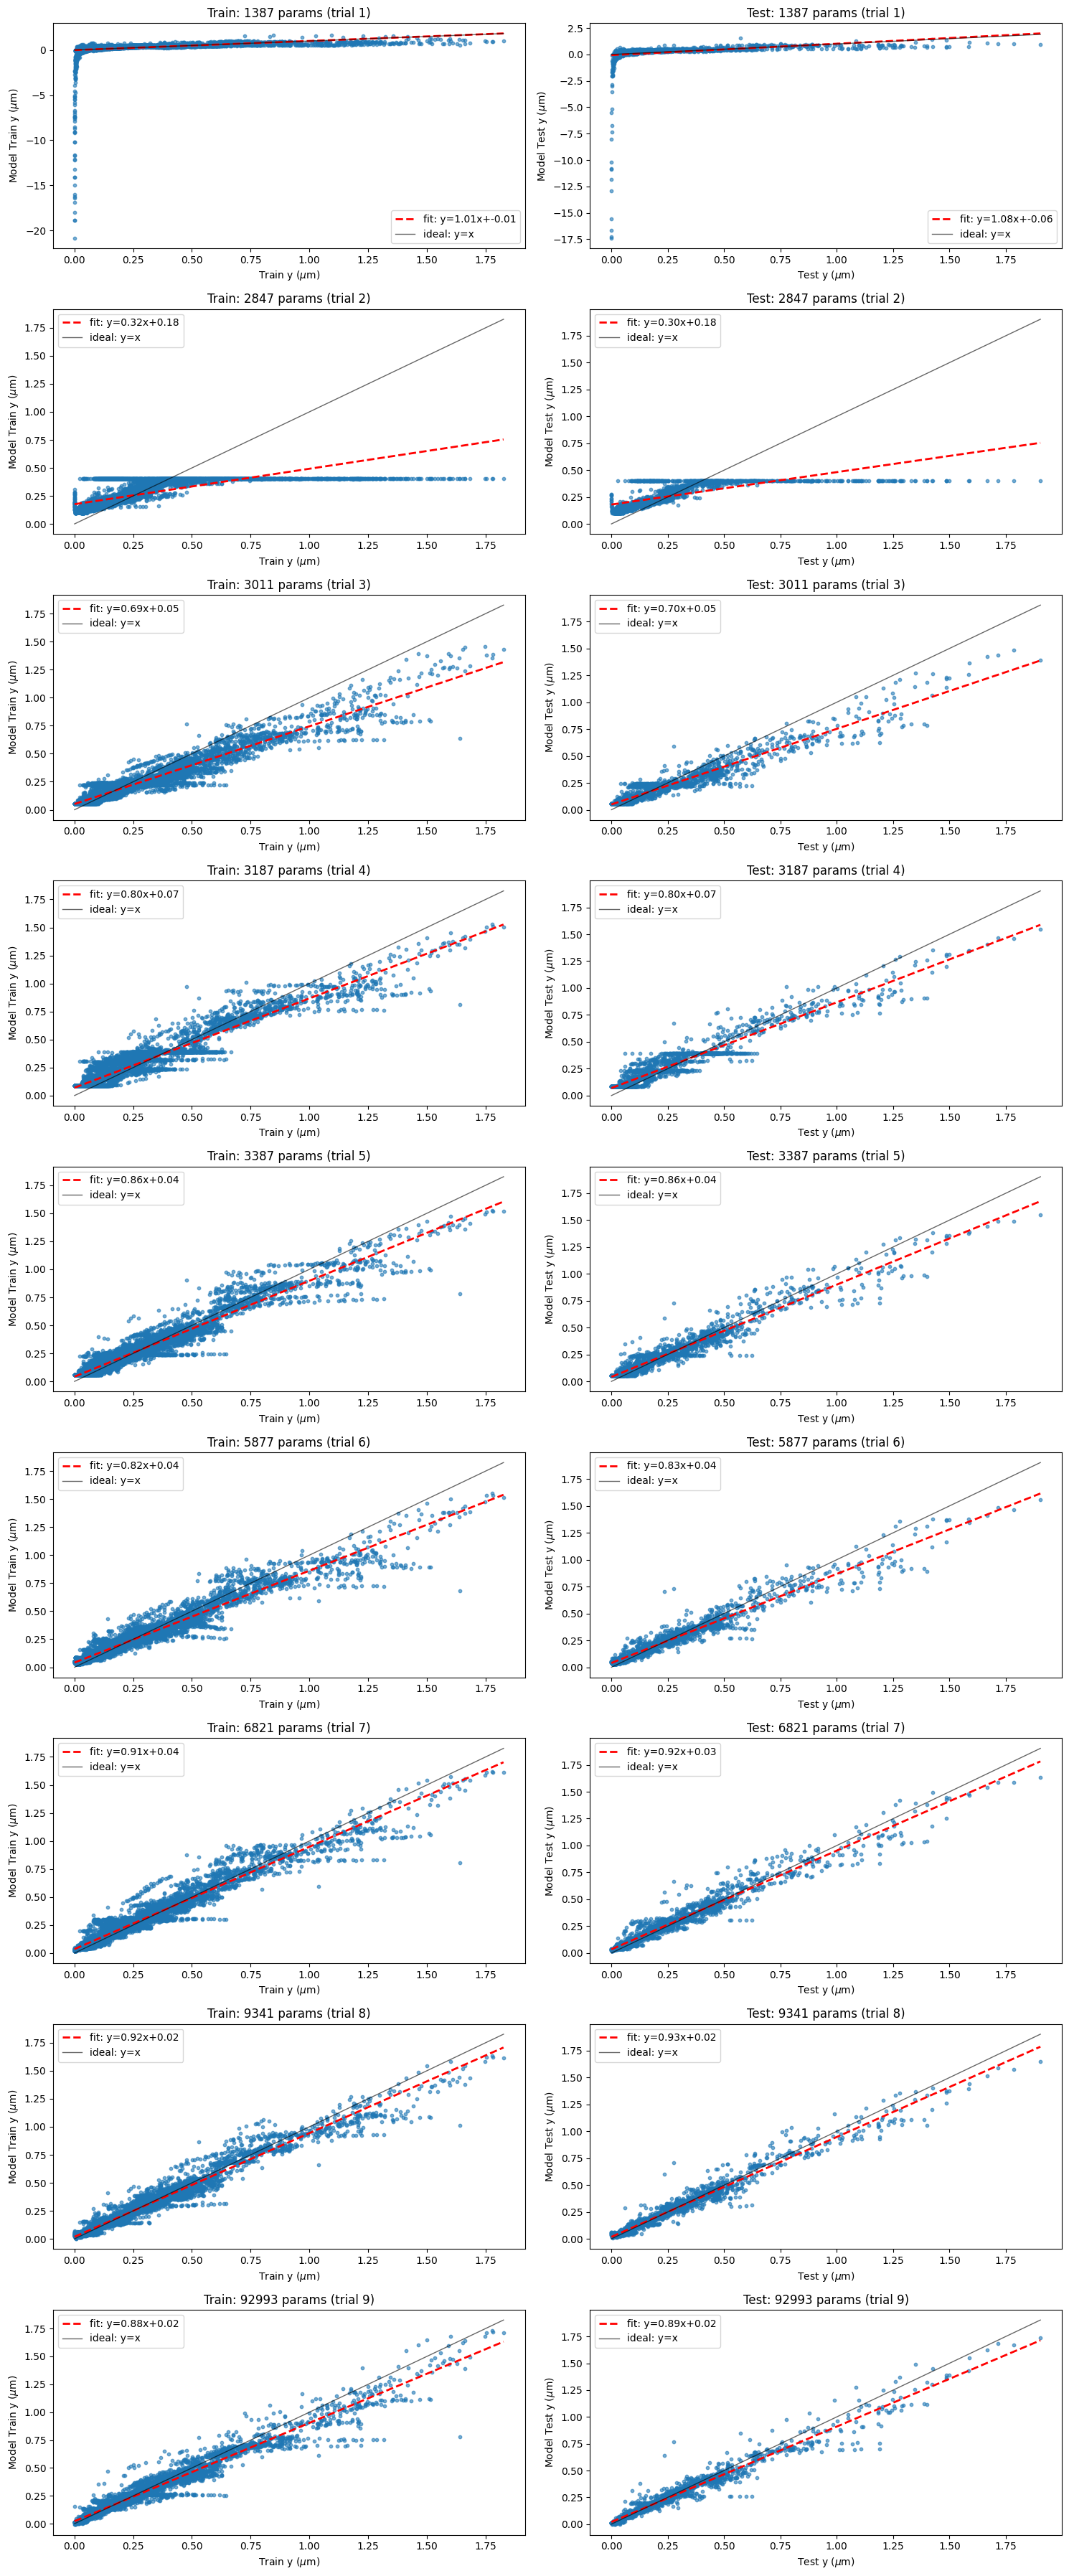

In [38]:
fig, axes = plt.subplots(len(df), 2, figsize=(15, 4*len(df)))
axes = np.atleast_2d(axes)

for i, row in df.reset_index(drop=True).iterrows():
    x_tr = np.asarray(row["train_y"], dtype=float)
    y_tr = np.asarray(row["train_model_y"], dtype=float)
    x_te = np.asarray(row["test_y"], dtype=float)
    y_te = np.asarray(row["test_model_y"], dtype=float)

    plot_scatter_with_fit(axes[i, 0], x_tr, y_tr)
    axes[i, 0].set_title(f'Train: {row["total_parameters"]} params (trial {row["trial_num"]})')
    axes[i, 0].set_xlabel(r"Train y ($\mu$m)")
    axes[i, 0].set_ylabel(r"Model Train y ($\mu$m)")

    plot_scatter_with_fit(axes[i, 1], x_te, y_te)
    axes[i, 1].set_title(f'Test: {row["total_parameters"]} params (trial {row["trial_num"]})')
    axes[i, 1].set_xlabel(r"Test y ($\mu$m)")
    axes[i, 1].set_ylabel(r"Model Test y ($\mu$m)")

plt.tight_layout()
plt.show()